In [15]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('nr_ic_merged.csv')

ERROR! Session/line number was not unique in database. History logging moved to new session 47


In [17]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [18]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b300>
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b370>
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b3e0>
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b450>
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b4c0>
...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e3319a0>
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e331a10>
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e331a80>
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e331af0>


In [19]:
FPSIZE = 1028
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [20]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b300>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b370>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b3e0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b450>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b4c0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e3319a0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e331a10>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e331a80>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e331af0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [21]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])

# Store each one-hot vector as a list
df['target_encoded'] = target_encoded.tolist()

In [22]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp,target_encoded
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b300>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b370>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b3e0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b450>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f830e59b4c0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e3319a0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e331a10>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e331a80>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f830e331af0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"


In [23]:
import numpy as np

# Convert fp arrays to tuples so they are hashable
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))

# Rename the aggregated target vector
df_agg = df_agg.rename(columns={'target_encoded': 'target'})

# Remove helper column
df_agg = df_agg.drop(columns=['fp_tuple'])

In [24]:
df_agg

,target,fp
0,"[1, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 1, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 0, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 0, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...
7201,"[0, 1, 0, 0, 0, 0]","[1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7202,"[0, 0, 1, 0, 0, 0]","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7203,"[0, 0, 0, 1, 0, 0]","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7204,"[0, 0, 0, 1, 0, 0]","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [25]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [26]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [27]:
import numpy as np
import scipy.stats

if not hasattr(np, 'NaN'):
    np.NaN = np.nan
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int

if not hasattr(scipy.stats, 'binom_test'):
    def binom_test_wrapper(x, n=None, p=0.5, alternative='two-sided'):
        k_clean = int(x)
        n_clean = int(n) if n is not None else None

        return scipy.stats.binomtest(k=k_clean, n=n_clean, p=p, alternative=alternative).pvalue

    scipy.stats.binom_test = binom_test_wrapper

from BorutaShap import BorutaShap
import pandas as pd

feature_names = [f"Bit_{i}" for i in range(x.shape[1])]
X_df = pd.DataFrame(x, columns=feature_names)

target_names = encoder.categories_[0]

print(f"Feature Matrix Shape: {X_df.shape}")
print(f"Targets to analyze: {target_names}")

Feature Matrix Shape: (7206, 1028)
Targets to analyze: ['ar' 'era' 'erb' 'gr' 'mr' 'pr']


In [28]:
import numpy as np

for i, name in enumerate(target_names):
    n_pos = y[:, i].sum()
    n_neg = y.shape[0] - n_pos
    print(f"{name}: positives={n_pos}, negatives={n_neg}")

ar: positives=1802, negatives=5404
era: positives=2424, negatives=4782
erb: positives=1500, negatives=5706
gr: positives=1630, negatives=5576
mr: positives=781, negatives=6425
pr: positives=1368, negatives=5838


In [29]:
import pandas as pd
import numpy as np
from BorutaShap import BorutaShap
from sklearn.ensemble import RandomForestClassifier

# --- 1. PREPARE DATA (Matches your Prediction Code) ---
# We assume 'x' and 'y' come from your df_agg logic (the de-duplicated data)

# Boruta needs a DataFrame with column names to report results
# We name columns 'bit_0', 'bit_1', etc.
feature_names = [f"bit_{i}" for i in range(x.shape[1])]
X_boruta = pd.DataFrame(x, columns=feature_names)

# --- 2. SETUP MODEL ---
# We use the same base model as your prediction code (Random Forest),
# BUT we add class_weight='balanced' to prevent the crash you saw earlier.
rf_model = RandomForestClassifier(
    n_estimators=100,       # Slightly higher than 40 is better for feature selection stability
    max_depth=7,            # Limits tree depth to prevent SHAP errors on pure leaves
    class_weight='balanced',# Critical for your imbalanced data (5404 vs 1802)
    n_jobs=-1
)

# --- 3. RUN BORUTA LOOP ---
selected_features_per_target = {}

# Loop through the columns of your Y matrix
# Assuming target_names is a list of your 6 target strings
for i, target_name in enumerate(target_names):

    print(f"Processing {target_name}...")

    # Extract the single column for this target
    y_target = pd.Series(y[:, i], name=target_name)

    # Initialize Boruta with your custom model
    selector = BorutaShap(
        model=rf_model,
        importance_measure='shap',
        classification=True
    )

    try:
        # sampling=False uses all data (recommended since you have ~7k rows)
        selector.fit(X=X_boruta, y=y_target, n_trials=20, sample=False, verbose=False)

        # Get the result
        subset = selector.Subset()
        selected_features = subset.columns.tolist()

        selected_features_per_target[target_name] = selected_features
        print(f"-> Selected {len(selected_features)} features for {target_name}")

    except Exception as e:
        print(f"-> Failed for {target_name}: {e}")

# Save results
import json
with open("boruta_results_final.json", "w") as f:
    json.dump(selected_features_per_target, f)

Processing ar...


  0%|          | 0/20 [00:06<?, ?it/s]


-> Failed for ar: list index out of range
Processing era...


  0%|          | 0/20 [00:06<?, ?it/s]


-> Failed for era: list index out of range
Processing erb...


  0%|          | 0/20 [00:06<?, ?it/s]


KeyboardInterrupt: 

In [37]:
print("\nSUMMARY OF IMPORTANT FINGERPRINT BITS:")
for target, features in selected_features_per_target.items():
    print(f"\nTarget: {target}")
    print(f"Count of Important Bits: {len(features)}")
    print(f"Top 10 Bits: {features[:10]} ...")

all_important_features = set()
for features in selected_features_per_target.values():
    all_important_features.update(features)

print(f"\nTotal unique important bits across all targets: {len(all_important_features)}")


SUMMARY OF IMPORTANT FINGERPRINT BITS:

Total unique important bits across all targets: 0


In [38]:
model = OneVsRestClassifier(
    RandomForestClassifier(
        n_estimators=25,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))

model.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,n_jobs,None
,verbose,0
,n_estimators,25
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None


In [39]:
import numpy as np

# Predict probabilities
y_pred_prob = model.predict_proba(x_test)

# Stack into a matrix: shape (n_samples, n_labels)
y_pred_prob_matrix = np.column_stack(y_pred_prob)
y_pred_prob_matrix = y_pred_prob_matrix.T

from sklearn.metrics import roc_auc_score

# ROC-AUC per target
roc_auc_per_target = [
    roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
    for i in range(y_test.shape[1])
]

print("ROC-AUC per target:", roc_auc_per_target)
print("Mean ROC-AUC:", np.mean(roc_auc_per_target))


ROC-AUC per target: [0.9758194802952083, 0.9855679336526243, 0.9768130888719124, 0.9796898945938162, 0.9703927392374875, 0.9508774453394707]
Mean ROC-AUC: 0.9731934303317532


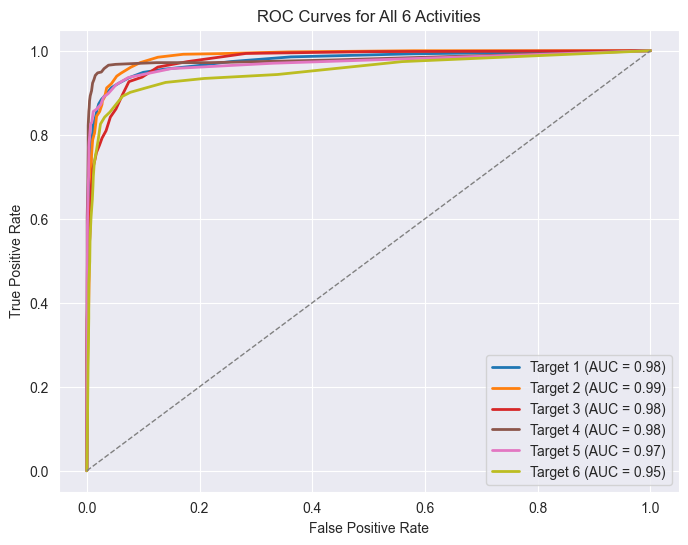

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib

n_targets = y_test.shape[1]
cmap = matplotlib.colormaps.get_cmap('tab10')

plt.figure(figsize=(8, 6))

for i in range(n_targets):
    fpr, tpr, thresholds = roc_curve(y_test[:, i], y_pred_prob_matrix[:, i])
    auc_score = roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
    color = cmap(i / n_targets)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"Target {i+1} (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All 6 Activities")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
